# 대만 대표기업 월별 매출 — 데이터 확인 & 시각화 (V7)

`revenue.db`(SQLite)에 저장된 실적/예측 데이터를 확인하고 시각화하는 노트북입니다.

사전 준비: 프로젝트 루트에서 아래를 먼저 실행해 DB에 데이터가 있어야 합니다.
```bash
python main.py collect --start 2019-01   # 과거 이력 수집
python main.py forecast --horizon 6      # 예측
```


In [24]:
# ============================================================
# [0] 범용 경로 부트스트랩 v2 — 노트북/데스크탑 어디서든 동작
#   ① config.py/db.py/forecaster.py 분리형 프로젝트 탐색
#      (config.py 가 실제로 setup_universal_paths 를 정의하는지 검증,
#       old_files/backup 등 백업 폴더는 감점)
#   ② 없으면 단일 파일형(tw_revenue*.py) 탐색 → config/db/forecaster 로 별칭 등록
#   자동 탐색 실패 시: os.environ["TW_PROJECT_DIR"] 로 직접 지정 후 재실행
# ============================================================
import os, sys, importlib.util
from pathlib import Path

SKIP = {".git", ".idea", ".venv", "venv", "env", "__pycache__", "node_modules",
        "site-packages", ".ipynb_checkpoints", "AppData", "anaconda3", "Miniconda3"}
BAD  = {"old_files", "old", "_old", "backup", "backups", "archive", "bak", "deprecated"}

def _iter_dirs():
    """탐색 대상 폴더 나열: cwd 하위(깊이 4) → 상위 3단계의 하위(깊이 2)."""
    seen = set()
    def walk(root, max_depth):
        root = Path(root); base = len(root.parts)
        for dp, dn, fn in os.walk(root):
            if len(Path(dp).parts) - base >= max_depth:
                dn[:] = []
            dn[:] = [d for d in dn if d not in SKIP and not d.startswith(".")]
            p = Path(dp)
            if p not in seen:
                seen.add(p)
                yield p, set(fn)
    yield from walk(Path.cwd(), 4)
    for parent in list(Path.cwd().parents)[:3]:
        yield from walk(parent, 2)

def _score(path):
    s = 0
    if (path / "revenue.db").exists(): s += 2        # 실DB 있으면 우선
    if set(path.parts) & BAD:          s -= 10       # 백업 폴더 감점
    return s

def _ver(f):
    """파일명에서 버전 번호 추출 (tw_revenue_V6.py → 6). 없으면 -1."""
    import re
    m = re.search(r"[Vv](\d+)", Path(f).stem)
    return int(m.group(1)) if m else -1

def find_tw_project():
    """(mode, path) 반환. mode: 'split' | 'single' | None"""
    env = os.environ.get("TW_PROJECT_DIR")
    if env:
        p = Path(env)
        names = {f.name for f in p.iterdir()} if p.exists() else set()
        if {"config.py", "db.py", "forecaster.py"} <= names:
            return "split", p
        single = [f for f in p.glob("tw_revenue*.py")]
        if single:
            return "single", max(single, key=lambda f: (_ver(f), f.stat().st_mtime))

    NEED = {"config.py", "db.py", "forecaster.py"}
    split_hits, single_hits = [], []
    for p, files in _iter_dirs():
        if NEED <= files:
            try:  # config.py 가 진짜 우리 프로젝트인지 내용 검증
                txt = (p / "config.py").read_text(encoding="utf-8", errors="ignore")
                if "def setup_universal_paths" in txt:
                    split_hits.append(p)
            except OSError:
                pass
        for f in files:
            if f.startswith("tw_revenue") and f.endswith(".py"):
                try:
                    txt = (p / f).read_text(encoding="utf-8", errors="ignore")
                    if "def setup_universal_paths" in txt:
                        single_hits.append(p / f)
                except OSError:
                    pass
    if split_hits:
        return "split", max(split_hits, key=lambda p: (_score(p), -len(p.parts)))
    if single_hits:
        # 같은 폴더에 여러 버전이 있으면 파일명 버전 번호가 큰 쪽(최신)을 선택,
        # 그래도 같으면 수정 시각이 최근인 파일을 선택
        best = max(single_hits, key=lambda f: (_score(f.parent), _ver(f),
                                               -len(f.parts), f.stat().st_mtime))
        others = sorted({f.name for f in single_hits if f != best})
        if others:
            print(f"[경로] 후보 {len(single_hits)}개 중 최신 버전 선택: {best.name} "
                  f"(제외: {', '.join(others)})")
        return "single", best
    return None, None

mode, target = find_tw_project()
if mode is None:
    raise FileNotFoundError(
        "대만 매출 프로젝트를 찾지 못했습니다 (config/db/forecaster 분리형 또는 tw_revenue*.py 단일형).\n"
        "아래처럼 프로젝트 폴더를 직접 지정한 뒤 이 셀을 다시 실행하세요:\n"
        '  import os; os.environ["TW_PROJECT_DIR"] = r"C:\\...\\Taiwan_Company"')

if mode == "split":
    if str(target) not in sys.path:
        sys.path.insert(0, str(target))
    print(f"[경로] 분리형 프로젝트: {target}")
else:
    # 단일 파일(tw_revenue_V4.py 등)을 import 하고 config/db/forecaster 별칭 등록
    print(f"[경로] 단일파일 프로젝트: {target}")
    spec = importlib.util.spec_from_file_location("tw_revenue_module", target)
    _m = importlib.util.module_from_spec(spec)
    sys.modules["tw_revenue_module"] = _m
    spec.loader.exec_module(_m)
    for alias in ("config", "db", "forecaster"):
        sys.modules[alias] = _m
    _missing = [a for a in ("setup_universal_paths", "COMPANIES", "get_conn",
                            "latest_basis", "forecast_company") if not hasattr(_m, a)]
    if _missing:
        print(f"[주의] 단일 파일에 없는 항목: {_missing} — 관련 셀은 실행 불가할 수 있음")

from config import setup_universal_paths
paths = setup_universal_paths()   # DATA 폴더 자동 탐색 (없어도 내장 엔진 사용)


[경로] 후보 3개 중 최신 버전 선택: tw_revenue_V6.py (제외: tw_revenue_V4.py, tw_revenue_V5.py)
[경로] 단일파일 프로젝트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\ODP\Taiwan_Company\tw_revenue_V6.py
경로 설정 완료
프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA 폴더:    C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


In [25]:
# 설정 및 DB 연결
import pandas as pd

# ============================================================
# matplotlib 백엔드 설정 — 'agg 라서 차트가 안 보임' 문제 근본 해결
#   ① MPLBACKEND=agg 강제 환경변수 무력화
#   ② Jupyter 커널이면 %matplotlib inline (셀 아래 표시)
#   ③ 아니면 TkAgg/QtAgg 등 GUI 백엔드 시도 (별도 창 표시)
#   ④ 전부 불가한 환경이라도 show_fig() 가 PNG 저장 + 자동 열기
# ============================================================
import os as _os
_os.environ.pop("MPLBACKEND", None)
import matplotlib

_BACKEND = None
try:
    _ip = get_ipython()                                   # Jupyter/IPython?
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
        _BACKEND = "inline"
except Exception:
    pass
if _BACKEND is None:
    import importlib as _il
    for _bk in ("TkAgg", "QtAgg", "Qt5Agg"):
        try:
            matplotlib.use(_bk, force=True)
            # use() 는 지연 로딩이라 여기서 실제 백엔드 모듈까지 import 해 검증
            _il.import_module(f"matplotlib.backends.backend_{_bk.lower()}")
            _BACKEND = _bk
            break
        except Exception:
            continue
    if _BACKEND is None:
        matplotlib.use("Agg", force=True)    # GUI 불가 확정 → show_fig 가 PNG 저장으로 처리
        _BACKEND = "Agg(파일 저장 모드)"
import matplotlib.pyplot as plt
print(f"[matplotlib] backend = {matplotlib.get_backend()}")

# 한글 폰트 자동 설정 (차트 제목/라벨의 한글 깨짐 방지)
from matplotlib import font_manager as _fm
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if any(ft.name == _font for ft in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

from pathlib import Path as _Path
CHART_DIR = _Path.cwd() / "charts"

def show_fig(fig=None):
    """어떤 환경에서도 차트를 보여주는 안전 출력.
    - inline/GUI 백엔드: 화면에 표시
    - agg 등 비GUI 백엔드: charts/ 폴더에 PNG 저장 후 기본 뷰어로 자동 열기"""
    fig = fig or plt.gcf()
    bk = matplotlib.get_backend().lower()
    if bk not in ("agg", "pdf", "ps", "svg", "template", "cairo"):
        plt.show()
        return
    import time
    CHART_DIR.mkdir(exist_ok=True)
    path = CHART_DIR / f"chart_{time.strftime('%Y%m%d_%H%M%S')}_{id(fig) % 1000:03d}.png"
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)
    print(f"[차트 저장] {path}")
    try:
        _os.startfile(path)      # Windows: 기본 이미지 뷰어로 자동 열기
    except (AttributeError, OSError):
        pass

from config import COMPANIES
from db import get_conn, latest_basis

pd.set_option("display.float_format", "{:,.1f}".format)
conn = get_conn()
COMPANIES

[matplotlib] backend = module://matplotlib_inline.backend_inline


{'2330': 'TSMC',
 '2308': 'Delta Electronics',
 '2454': 'MediaTek',
 '2317': 'Hon Hai (Foxconn)',
 '3711': 'ASE Technology',
 '2383': 'Elite Material',
 '3037': 'Unimicron',
 '2345': 'Accton Technology',
 '2881': 'Fubon Financial',
 '2382': 'Quanta Computer',
 '2882': 'Cathay Financial',
 '3017': 'Asia Vital Components',
 '2412': 'Chunghwa Telecom',
 '2891': 'CTBC Financial',
 '2303': 'UMC',
 '2360': 'Chroma ATE',
 '7769': 'Grand Process Tech',
 '6669': 'Wiwynn',
 '3653': 'Jentech Precision',
 '1303': 'Nan Ya Plastics',
 '2368': 'Gold Circuit Electronics',
 '2885': 'Yuanta Financial',
 '2408': 'Nanya Technology',
 '2327': 'Yageo',
 '8046': 'Nan Ya PCB',
 '2887': 'Taishin Shinkong Financial',
 '2886': 'Mega Financial',
 '3443': 'Global Unichip',
 '3665': 'BizLink-KY',
 '6505': 'Formosa Petrochemical',
 '2884': 'E.SUN Financial',
 '4958': 'Zhen Ding-KY',
 '2890': 'SinoPac Financial',
 '2880': 'Hua Nan Financial',
 '2603': 'Evergreen Marine',
 '3231': 'Wistron',
 '2357': 'ASUSTeK',
 '3045

## 1. 데이터 현황 확인

In [26]:
# 테이블별 건수와 기업별 수집 범위
summary = pd.read_sql("""
SELECT company_id,
       MAX(company_name)                        AS name,
       COUNT(*)                                 AS n_months,
       MIN(year || '-' || printf('%02d', month)) AS first_month,
       MAX(year || '-' || printf('%02d', month)) AS last_month
FROM revenue GROUP BY company_id ORDER BY company_id
""", conn)
print("revenue rows :", conn.execute("SELECT COUNT(*) FROM revenue").fetchone()[0])
print("forecast rows:", conn.execute("SELECT COUNT(*) FROM forecast").fetchone()[0])
summary

revenue rows : 4330
forecast rows: 5208


,company_id,name,n_months,first_month,last_month
0,1216,Uni-President,92,2019-01,2026-08
1,1301,Formosa Plastics,92,2019-01,2026-08
2,1303,Nan Ya Plastics,92,2019-01,2026-08
3,2059,King Slide Works,92,2019-01,2026-08
4,2301,Lite-On Technology,92,2019-01,2026-08
5,2303,UMC,92,2019-01,2026-08
6,2308,Delta Electronics,92,2019-01,2026-08
7,2317,Hon Hai (Foxconn),92,2019-01,2026-08
8,2327,Yageo,92,2019-01,2026-08
9,2330,TSMC,92,2019-01,2026-08


In [27]:
# 최근 6개월 실적 미리보기 (전 기업)
recent = pd.read_sql("""
SELECT company_id, company_name, year, month,
       revenue/1e6 AS revenue_bil, mom_pct, yoy_pct, source
FROM revenue
ORDER BY year DESC, month DESC, company_id
LIMIT 30
""", conn)
recent

,company_id,company_name,year,month,revenue_bil,mom_pct,yoy_pct,source
0,1216,Uni-President,2026,8,63.1,1.5,3.8,openapi
1,1301,Formosa Plastics,2026,8,14.0,-8.5,6.8,openapi
2,1303,Nan Ya Plastics,2026,8,30.6,0.1,46.7,openapi
3,2059,King Slide Works,2026,8,6.5,0.9,344.4,openapi
4,2301,Lite-On Technology,2026,8,19.6,3.1,25.2,openapi
5,2303,UMC,2026,8,25.0,5.0,30.7,openapi
6,2308,Delta Electronics,2026,8,64.6,-3.7,34.9,openapi
7,2317,Hon Hai (Foxconn),2026,8,921.8,-2.6,52.0,openapi
8,2327,Yageo,2026,8,16.3,1.2,51.8,openapi
9,2330,TSMC,2026,8,514.8,10.1,53.3,openapi


In [28]:
# 예측 이력 확인 (basis = 예측에 사용한 마지막 실적 연월)
fc = pd.read_sql("""
SELECT company_id,
       basis_year  || '-' || printf('%02d', basis_month)  AS basis,
       target_year || '-' || printf('%02d', target_month) AS target,
       predicted/1e6 AS pred_bil,
       lower_95/1e6  AS lo_bil,
       upper_95/1e6  AS hi_bil,
       model
FROM forecast ORDER BY company_id, basis, target
""", conn)
fc.head(15)

,company_id,basis,target,pred_bil,lo_bil,hi_bil,model
0,1216,2026-06,2026-07,61.9,None,None,ensemble
1,1216,2026-06,2026-07,62.0,None,None,ets
2,1216,2026-06,2026-07,60.5,None,None,sarima
3,1216,2026-06,2026-07,63.0,None,None,theta
4,1216,2026-06,2026-08,64.0,None,None,ensemble
5,1216,2026-06,2026-08,63.2,None,None,ets
6,1216,2026-06,2026-08,63.8,None,None,sarima
7,1216,2026-06,2026-08,64.9,None,None,theta
8,1216,2026-06,2026-09,61.4,None,None,ensemble
9,1216,2026-06,2026-09,61.2,None,None,ets


## 2. 기업별 시계열 조회

`CID`를 바꿔 원하는 기업을 확인하세요.

In [29]:
CID = "2408"        # ← 종목코드 변경
MODEL = "ensemble"  # ← 예측 모델 선택: sarima / theta / ets / ensemble

def actual_df(cid):
    df = pd.read_sql(
        "SELECT year, month, revenue, mom_pct, yoy_pct FROM revenue "
        "WHERE company_id = ? ORDER BY year, month", conn, params=(cid,))
    df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
    df["revenue_bil"] = df["revenue"] / 1e6   # NTD 천 → 십억
    return df

def forecast_df(cid, basis=None, model=None):
    q = ("SELECT basis_year, basis_month, target_year, target_month, "
         "predicted, lower_95, upper_95, model FROM forecast WHERE company_id = ?")
    params = [cid]
    if basis:
        q += " AND basis_year = ? AND basis_month = ?"
        params += list(basis)
    if model:
        q += " AND model = ?"
        params.append(model)
    df = pd.read_sql(q + " ORDER BY target_year, target_month", conn, params=params)
    if df.empty:
        return df
    df["date"] = pd.to_datetime(dict(year=df.target_year, month=df.target_month, day=1))
    for c in ("predicted", "lower_95", "upper_95"):
        # NULL(예: ensemble 은 CI 미저장)이 섞이면 object 타입이 되므로 숫자로 강제 변환
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c + "_bil"] = df[c] / 1e6
    return df

a = actual_df(CID)
a.tail(12)

,year,month,revenue,mom_pct,yoy_pct,date,revenue_bil
80,2025,9,6664140,-1.4,157.8,2025-09-01,6.7
81,2025,10,7907729,18.7,262.4,2025-10-01,7.9
82,2025,11,10168737,28.6,364.9,2025-11-01,10.2
83,2025,12,12017152,18.2,444.9,2025-12-01,12.0
84,2026,1,15309988,27.4,608.0,2026-01-01,15.3
85,2026,2,15607184,1.9,586.7,2026-02-01,15.6
86,2026,3,18169760,16.4,560.0,2026-03-01,18.2
87,2026,4,25491201,40.3,717.3,2026-04-01,25.5
88,2026,5,27669563,8.5,730.1,2026-05-01,27.7
89,2026,6,29388309,6.2,621.3,2026-06-01,29.4


## 3. 시각화

### 3-1. 실적 + 최신 예측 (95% 신뢰구간)

[안내] 'ensemble' 모델은 신뢰구간이 저장되어 있지 않아 CI 음영은 생략합니다.


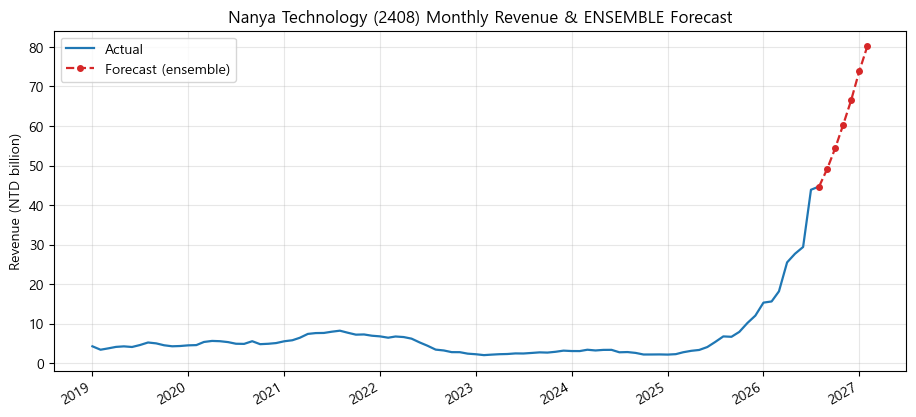

In [30]:
basis = latest_basis(conn, CID)
f = forecast_df(CID, basis=basis, model=MODEL)
name = COMPANIES.get(CID, CID)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(a["date"], a["revenue_bil"], label="Actual", color="#1f77b4", lw=1.6)
if not f.empty:
    last = a.iloc[-1]
    ax.plot([last["date"], *f["date"]], [last["revenue_bil"], *f["predicted_bil"]],
            "--o", color="#d62728", ms=4, lw=1.6, label=f"Forecast ({MODEL})")
    ci = f.dropna(subset=["lower_95_bil", "upper_95_bil"])
    if not ci.empty:
        ax.fill_between(ci["date"], ci["lower_95_bil"], ci["upper_95_bil"],
                        color="#d62728", alpha=0.15, label="95% CI")
    else:
        print(f"[안내] '{MODEL}' 모델은 신뢰구간이 저장되어 있지 않아 CI 음영은 생략합니다.")
ax.set_title(f"{name} ({CID}) Monthly Revenue & {MODEL.upper()} Forecast")
ax.set_ylabel("Revenue (NTD billion)")
ax.grid(alpha=0.3); ax.legend(); fig.autofmt_xdate()
show_fig(fig)

### 3-2. 과거 예측 이력 vs 실적 (매월 예측 추적)

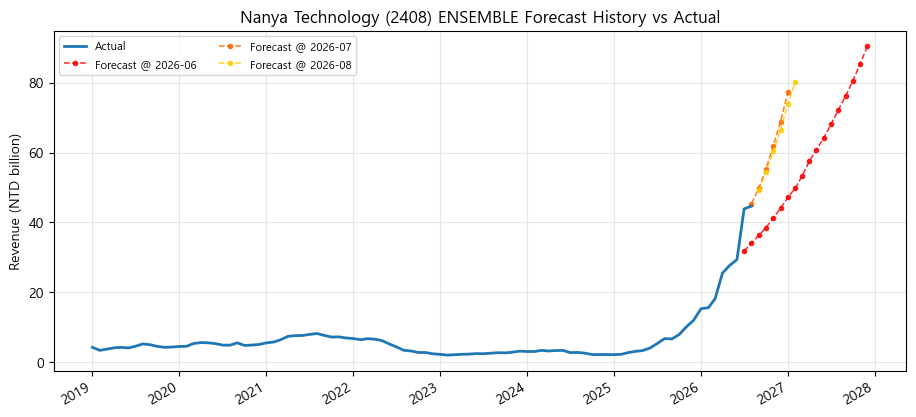

In [31]:
all_f = forecast_df(CID, model=MODEL)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(a["date"], a["revenue_bil"], label="Actual", color="#1f77b4", lw=2, zorder=5)
if not all_f.empty:
    bases = sorted(set(zip(all_f.basis_year, all_f.basis_month)))
    cmap = plt.get_cmap("autumn")
    for i, (by, bm) in enumerate(bases):
        g = all_f[(all_f.basis_year == by) & (all_f.basis_month == bm)]
        ax.plot(g["date"], g["predicted_bil"], "--.", ms=6, lw=1.1, alpha=0.85,
                color=cmap(i / max(len(bases) - 1, 1) * 0.8),
                label=f"Forecast @ {by}-{bm:02d}")
ax.set_title(f"{name} ({CID}) {MODEL.upper()} Forecast History vs Actual")
ax.set_ylabel("Revenue (NTD billion)")
ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2); fig.autofmt_xdate()
show_fig(fig)

### 3-2b. 4개 모델 최신 예측 비교

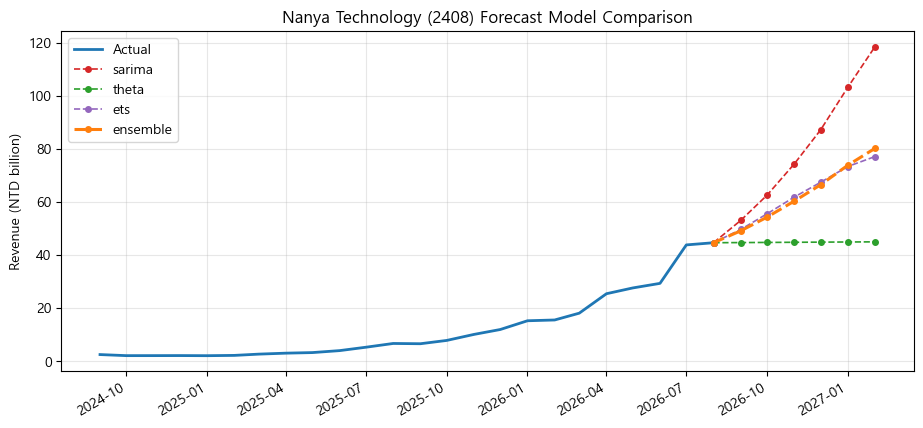

In [32]:
colors = {"sarima": "#d62728", "theta": "#2ca02c", "ets": "#9467bd", "ensemble": "#ff7f0e"}
fall = forecast_df(CID, basis=basis)  # 최신 basis의 전체 모델
fig, ax = plt.subplots(figsize=(11, 5))
tail = a.tail(24)
ax.plot(tail["date"], tail["revenue_bil"], label="Actual", color="#1f77b4", lw=2)
last = a.iloc[-1]
if not fall.empty:
    fall["date"] = pd.to_datetime(dict(year=fall.target_year, month=fall.target_month, day=1))
    fall["pred_bil"] = pd.to_numeric(fall["predicted"], errors="coerce") / 1e6
    for mname, c in colors.items():
        g = fall[fall.model == mname].sort_values("date")
        if g.empty:
            continue
        lw = 2.2 if mname == "ensemble" else 1.2
        ax.plot([last["date"], *g["date"]], [last["revenue_bil"], *g["pred_bil"]],
                "--o", ms=4, lw=lw, color=c, label=mname)
ax.set_title(f"{name} ({CID}) Forecast Model Comparison")
ax.set_ylabel("Revenue (NTD billion)")
ax.grid(alpha=0.3); ax.legend(); fig.autofmt_xdate()
show_fig(fig)

### 3-3. 전년 동월 대비 증감률(YoY)

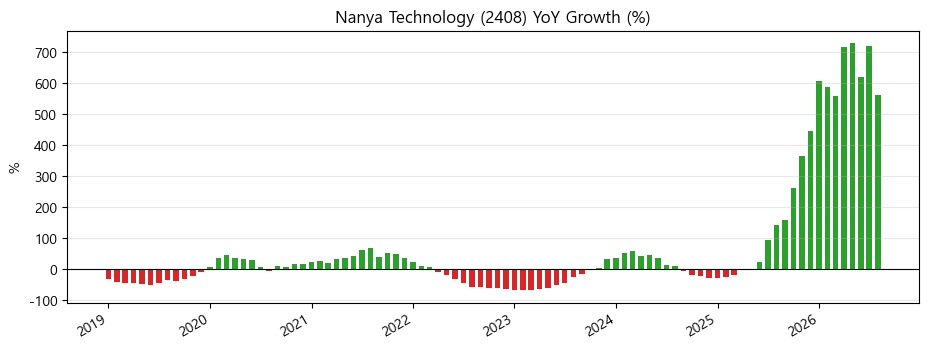

In [33]:
yoy = a.dropna(subset=["yoy_pct"]) if a["yoy_pct"].notna().any() else None
if yoy is None or yoy.empty:
    # DB에 yoy가 없으면 직접 계산
    tmp = a.set_index("date")["revenue"].astype(float)
    yoy_series = (tmp / tmp.shift(12) - 1) * 100
    yoy = yoy_series.dropna().rename("yoy_pct").reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in yoy["yoy_pct"]]
ax.bar(yoy["date"], yoy["yoy_pct"], width=20, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"{name} ({CID}) YoY Growth (%)")
ax.set_ylabel("%"); ax.grid(alpha=0.3, axis="y"); fig.autofmt_xdate()
show_fig(fig)

### 3-4. 전체 기업 비교 (지수화: 시작월 = 100)

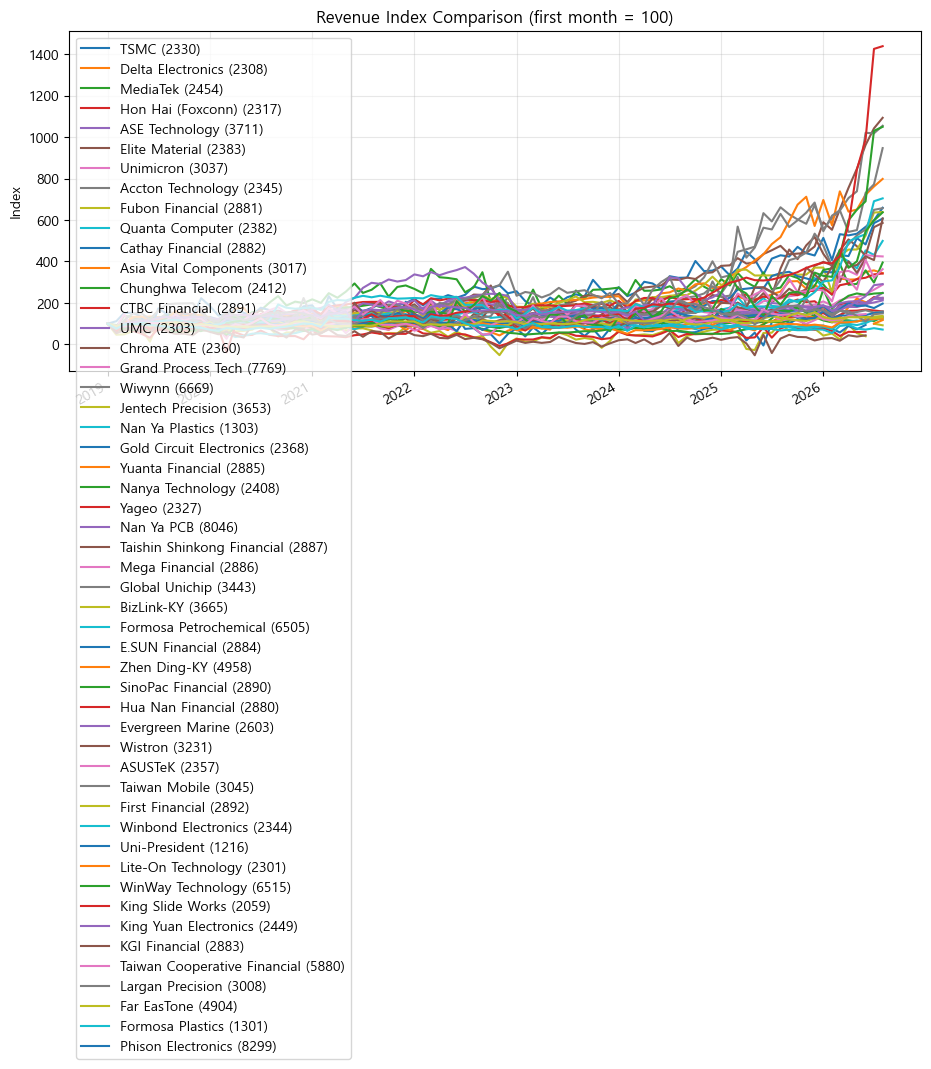

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
for cid, cname in COMPANIES.items():
    d = actual_df(cid)
    if d.empty:
        continue
    idx = d["revenue"].astype(float) / float(d["revenue"].iloc[0]) * 100
    ax.plot(d["date"], idx, lw=1.5, label=f"{cname} ({cid})")
ax.set_title("Revenue Index Comparison (first month = 100)")
ax.set_ylabel("Index"); ax.grid(alpha=0.3); ax.legend(); fig.autofmt_xdate()
show_fig(fig)

## 4. ticker 리스트 → 실적 + 예측 결합 데이터프레임

대만 종목코드를 **리스트로 입력**하면 각 기업의 과거 매출 실적과 최신 basis의
향후 예측(기본 `ensemble`)을 이어붙인 DataFrame을 반환합니다.
- `kind` 컬럼: `actual`(실적) / `forecast`(예측) 구분
- 예측은 각 기업의 **마지막 실적 이후 월만** 사용 (실적과 겹치지 않음)
- 단위: `revenue`=NTD 천(원본), `revenue_bil`=NTD 십억

In [35]:
# ★ 종목코드 리스트 입력 ★
# TICKERS  = ["2330", "2454", "2317", "2408", "2344", "2059","6515", "3446",
#             "2360", "2383", "2382", "7769", "2368", "3231", "3017", "2308", "8046"]   # ← 원하는 대만 종목코드들

# ★ 종목코드 리스트 입력 ★ — DB에 수집된 전체 기업 자동 로드
TICKERS = pd.read_sql(
    "SELECT DISTINCT company_id FROM revenue ORDER BY company_id", conn
)["company_id"].astype(str).tolist()

print(f"전체 {len(TICKERS)}개 기업:", TICKERS)

FC_MODEL = "ensemble"                  # sarima / theta / ets / ensemble

def combined_revenue(tickers, model="ensemble"):
    """실적 + 최신 basis 예측 결합.
    Returns: (long_df, wide_rev, wide_kind)
      long_df  : [company_id, company_name, date, revenue, revenue_bil,
                  lower_95, upper_95, kind]
      wide_rev : index=date, columns=종목코드, 값=매출(실적+예측, NTD 십억)
      wide_kind: 같은 모양, 값='actual'/'forecast' — 어느 월부터 예측인지 확인용
    """
    import numpy as np
    longs = []
    for cid in tickers:
        a = actual_df(cid)
        if a.empty:
            print(f"[경고] {cid}: 실적 데이터 없음 — 건너뜀")
            continue
        a2 = a[["date", "revenue"]].copy()
        a2["lower_95"] = np.nan; a2["upper_95"] = np.nan
        a2["kind"] = "actual"

        b = latest_basis(conn, cid)
        f = forecast_df(cid, basis=b, model=model) if b else pd.DataFrame()
        if not f.empty:
            f2 = (f[f["date"] > a["date"].max()]
                  [["date", "predicted", "lower_95", "upper_95"]]
                  .rename(columns={"predicted": "revenue"}))
            f2["kind"] = "forecast"
            a2 = pd.concat([a2, f2], ignore_index=True)
        else:
            print(f"[안내] {cid}: '{model}' 예측 없음 — 실적만 포함")

        a2.insert(0, "company_name", COMPANIES.get(cid, cid))
        a2.insert(0, "company_id", cid)
        longs.append(a2)

    if not longs:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    long_df = (pd.concat(longs, ignore_index=True)
                 .sort_values(["company_id", "date"]).reset_index(drop=True))
    long_df["revenue_bil"] = long_df["revenue"] / 1e6
    wide_rev = (long_df.pivot_table(index="date", columns="company_id",
                                    values="revenue_bil", aggfunc="last")
                       .sort_index())
    wide_kind = long_df.pivot_table(index="date", columns="company_id",
                                    values="kind", aggfunc="last").sort_index()
    return long_df, wide_rev, wide_kind

combo_long, combo_wide, combo_kind = combined_revenue(TICKERS, model=FC_MODEL)
n_fc = int((combo_long["kind"] == "forecast").sum())
print(f"총 {combo_long['company_id'].nunique()}개 기업, {len(combo_long)}행 (예측 {n_fc}행)")
combo_long[combo_long["kind"] == "forecast"].head(12)   # 예측 구간 미리보기

전체 51개 기업: ['1216', '1301', '1303', '2059', '2301', '2303', '2308', '2317', '2327', '2330', '2344', '2345', '2357', '2360', '2368', '2382', '2383', '2408', '2412', '2449', '2454', '2603', '2880', '2881', '2882', '2883', '2884', '2885', '2886', '2887', '2890', '2891', '2892', '3008', '3017', '3037', '3045', '3231', '3443', '3653', '3665', '3711', '4904', '4958', '5880', '6505', '6515', '6669', '7769', '8046', '8299']
[안내] 3665: 'ensemble' 예측 없음 — 실적만 포함
[안내] 4958: 'ensemble' 예측 없음 — 실적만 포함
[안내] 7769: 'ensemble' 예측 없음 — 실적만 포함
[안내] 8299: 'ensemble' 예측 없음 — 실적만 포함
총 51개 기업, 4708행 (예측 378행)


,company_id,company_name,date,revenue,lower_95,upper_95,kind,revenue_bil
92,1216,Uni-President,2026-09-01,"61,119,076.3",NaN,NaN,forecast,61.1
93,1216,Uni-President,2026-10-01,"57,374,442.8",NaN,NaN,forecast,57.4
94,1216,Uni-President,2026-11-01,"55,132,974.7",NaN,NaN,forecast,55.1
95,1216,Uni-President,2026-12-01,"55,364,363.6",NaN,NaN,forecast,55.4
96,1216,Uni-President,2027-01-01,"66,771,572.9",NaN,NaN,forecast,66.8
97,1216,Uni-President,2027-02-01,"52,627,441.5",NaN,NaN,forecast,52.6
190,1301,Formosa Plastics,2026-09-01,"14,079,457.4",NaN,NaN,forecast,14.1
191,1301,Formosa Plastics,2026-10-01,"14,182,475.6",NaN,NaN,forecast,14.2
192,1301,Formosa Plastics,2026-11-01,"14,745,605.6",NaN,NaN,forecast,14.7
193,1301,Formosa Plastics,2026-12-01,"14,467,749.8",NaN,NaN,forecast,14.5


In [45]:
combo_long.to_excel(r"C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\대만기업_월별매출분석\tw_actual_forecast_202608.xlsx")

In [37]:
# 결합 wide (NTD 십억) — 마지막 15개월: 실적에서 예측으로 넘어가는 구간 확인
display(combo_wide.tail(15).round(1))
combo_kind.tail(15)   # 같은 위치가 actual 인지 forecast 인지

company_id,1216,1301,1303,2059,2301,2303,2308,2317,2327,2330,...,3711,4904,4958,5880,6505,6515,6669,7769,8046,8299
date,,,,,,,,,,,,,,,,,,,,,
2026-10-01,57.4,14.2,31.8,7.7,19.6,25.5,67.3,"1,238.7",16.4,543.6,...,84.9,11.4,NaN,5.9,77.0,1.7,142.4,NaN,5.5,NaN
2026-11-01,55.1,14.7,31.9,8.5,19.5,25.3,65.1,"1,183.1",16.7,527.8,...,84.0,11.0,NaN,6.1,76.8,1.7,146.3,NaN,5.4,NaN
2026-12-01,55.4,14.5,32.6,8.8,19.6,24.6,67.1,"1,185.1",16.4,514.7,...,82.6,11.6,NaN,6.3,79.4,1.7,150.7,NaN,5.6,NaN
2027-01-01,66.8,13.6,32.2,9.4,18.2,25.2,62.7,"1,024.1",17.0,552.0,...,77.1,10.6,NaN,6.3,81.4,1.8,144.8,NaN,5.4,NaN
2027-02-01,52.6,13.2,31.6,9.6,16.3,24.4,60.2,880.2,16.7,493.6,...,69.4,10.0,NaN,5.7,77.9,1.8,152.4,NaN,5.1,NaN
2027-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.3,NaN,NaN,NaN,NaN,NaN,NaN
2027-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.1,NaN,NaN,NaN,NaN,NaN,NaN
2027-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.1,NaN,NaN,NaN,NaN,NaN,NaN
2027-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.2,NaN,NaN,NaN,NaN,NaN,NaN


company_id,1216,1301,1303,2059,2301,2303,2308,2317,2327,2330,...,3711,4904,4958,5880,6505,6515,6669,7769,8046,8299
date,,,,,,,,,,,,,,,,,,,,,
2026-10-01,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,...,forecast,forecast,NaN,forecast,forecast,forecast,forecast,NaN,forecast,NaN
2026-11-01,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,...,forecast,forecast,NaN,forecast,forecast,forecast,forecast,NaN,forecast,NaN
2026-12-01,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,...,forecast,forecast,NaN,forecast,forecast,forecast,forecast,NaN,forecast,NaN
2027-01-01,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,...,forecast,forecast,NaN,forecast,forecast,forecast,forecast,NaN,forecast,NaN
2027-02-01,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,forecast,...,forecast,forecast,NaN,forecast,forecast,forecast,forecast,NaN,forecast,NaN
2027-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,forecast,NaN,NaN,NaN,NaN,NaN,NaN
2027-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,forecast,NaN,NaN,NaN,NaN,NaN,NaN
2027-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,forecast,NaN,NaN,NaN,NaN,NaN,NaN
2027-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,forecast,NaN,NaN,NaN,NaN,NaN,NaN


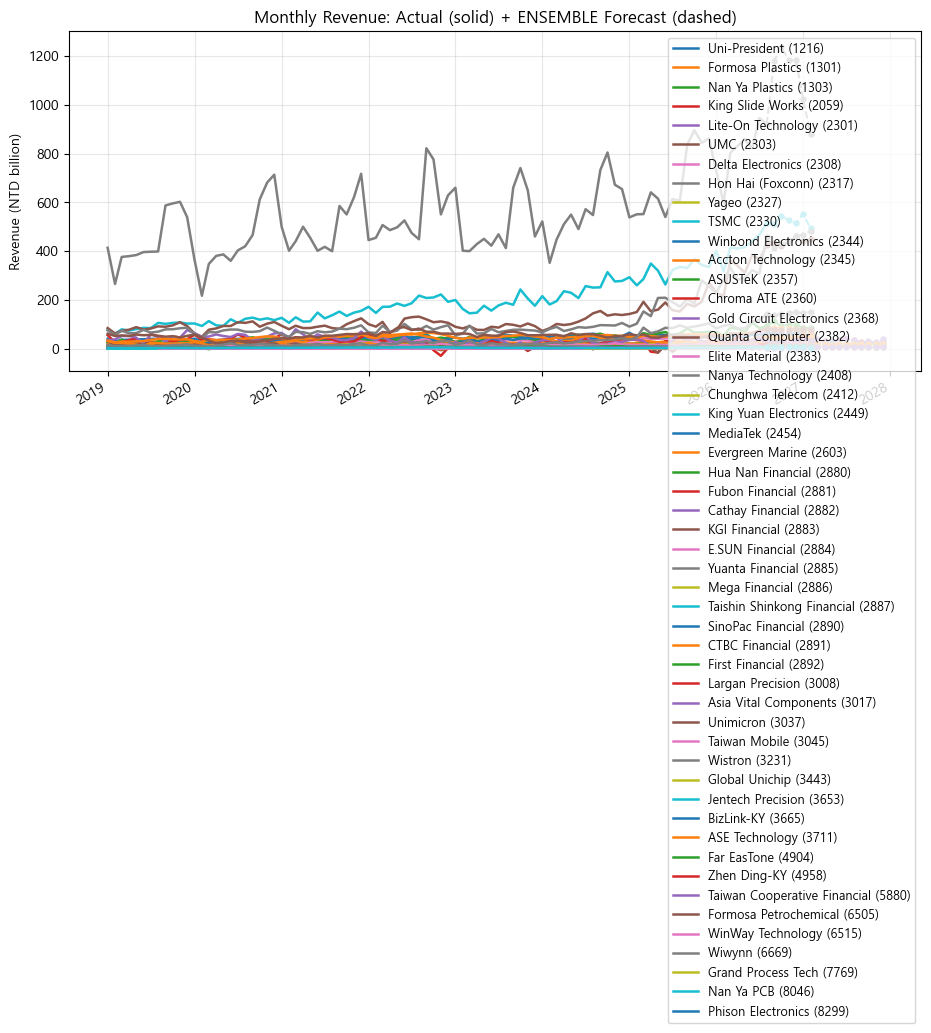

In [38]:
# 결합 시계열 차트: 실선=실적, 점선=예측
fig, ax = plt.subplots(figsize=(11, 5))
for cid in combo_wide.columns:
    g  = combo_long[combo_long["company_id"] == cid]
    ga = g[g["kind"] == "actual"];  gf = g[g["kind"] == "forecast"]
    ln, = ax.plot(ga["date"], ga["revenue_bil"], lw=1.8,
                  label=f'{COMPANIES.get(cid, cid)} ({cid})')
    if not gf.empty:
        ax.plot([ga["date"].iloc[-1], *gf["date"]],
                [ga["revenue_bil"].iloc[-1], *gf["revenue_bil"]],
                "--o", ms=3.5, lw=1.4, color=ln.get_color())
ax.set_title(f"Monthly Revenue: Actual (solid) + {FC_MODEL.upper()} Forecast (dashed)")
ax.set_ylabel("Revenue (NTD billion)")
ax.grid(alpha=0.3); ax.legend(fontsize=9); fig.autofmt_xdate()
show_fig(fig)

## 4-2. 통합 조회 — `analyze()` (V7)
- **ticker 하나(문자열)** 입력 → **3단 비교 차트**
  1) 실적 + 4개 모델 최신 예측 비교
  2) 실적 YoY Growth (%)
  3) ★ **예측 반영 YoY Growth (%)** — `fc_model`(기본 `ensemble`, 수동 변경 가능) 예측치를
     실적 뒤에 이어붙여 **미래 월의 YoY** 까지 표시 (빗금 = 예측 구간).
     성장 모멘텀이 언제 둔화/가속되는지 미리 가늠하는 용도이며,
     최근 3개월 실적 YoY 평균 vs 예측 구간 평균의 모멘텀 진단도 함께 출력됨.
- **ticker 리스트** 입력 → DB에 저장된 **과거 예측 이력 DataFrame** (실제치가 나온 구간은 오차율까지 계산)

In [39]:
MODEL_COLORS = {"sarima": "#d62728", "theta": "#2ca02c",
                "ets": "#9467bd", "ensemble": "#ff7f0e"}

def compare_chart(cid, months=36, fc_model="ensemble"):
    """단일 종목 비교 차트 (V7: 3단 구성).
      (상) 최근 실적 + 최신 basis 의 4개 모델 예측 비교
      (중) 실적 YoY Growth (%)
      (하) ★ 예측 반영 YoY Growth (%) — fc_model(기본 ensemble) 예측치를
           실적 뒤에 이어붙여 미래 월의 YoY 까지 계산.
           → 매출 성장 모멘텀이 언제 둔화/가속되는지 미리 가늠 가능.
    fc_model 은 "sarima" / "theta" / "ets" / "ensemble" 로 수동 변경 가능.
    """
    a = actual_df(cid)
    if a.empty:
        print(f"[경고] {cid}: 실적 데이터 없음"); return
    b = latest_basis(conn, cid)
    fall = forecast_df(cid, basis=b) if b else pd.DataFrame()
    name = COMPANIES.get(cid, cid)

    fig, axes = plt.subplots(3, 1, figsize=(11, 10),
                             gridspec_kw={"height_ratios": [2, 1, 1.2]})

    # ---------- (상) 매출 + 모델별 예측 ----------
    ax = axes[0]
    tail = a.tail(months)
    ax.plot(tail["date"], tail["revenue_bil"], color="#1f77b4", lw=2, label="Actual")
    last = a.iloc[-1]
    for mname, clr in MODEL_COLORS.items():
        g = fall[fall["model"] == mname].sort_values("date") if not fall.empty else pd.DataFrame()
        if g.empty:
            continue
        lw = 2.2 if mname == "ensemble" else 1.2
        ax.plot([last["date"], *g["date"]], [last["revenue_bil"], *g["predicted_bil"]],
                "--o", ms=4, lw=lw, color=clr, label=mname)
    btxt = f" (basis {b[0]}-{b[1]:02d})" if b else " (예측 없음)"
    ax.set_title(f"{name} ({cid}) — Actual vs Model Forecasts{btxt}")
    ax.set_ylabel("Revenue (NTD billion)")
    ax.grid(alpha=0.3); ax.legend(fontsize=9, ncol=2)

    # ---------- 공통: 실적 시계열 / YoY ----------
    t = a.set_index("date")["revenue"].astype(float)
    yoy_act = ((t / t.shift(12) - 1) * 100).dropna()

    # ---------- (중) 실적 YoY ----------
    ax2 = axes[1]
    ya = yoy_act.tail(months)
    ax2.bar(ya.index, ya.values, width=20,
            color=["#2ca02c" if v >= 0 else "#d62728" for v in ya.values])
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_title("YoY Growth (%) — Actual")
    ax2.set_ylabel("%"); ax2.grid(alpha=0.3, axis="y")

    # ---------- (하) ★ 예측 반영 YoY ----------
    ax3 = axes[2]
    g = (fall[fall["model"] == fc_model].sort_values("date")
         if not fall.empty else pd.DataFrame())
    if g.empty:
        ax3.text(0.5, 0.5, f"no '{fc_model}' forecast data",
                 ha="center", va="center", transform=ax3.transAxes)
        ax3.set_title(f"YoY Growth with Forecast (%) — {fc_model}")
    else:
        fc = g.set_index("date")["predicted"].astype(float)
        fc = fc[fc.index > t.index.max()]            # 실적 이후 월만
        combined = pd.concat([t, fc]).sort_index()
        yoy_all = ((combined / combined.shift(12) - 1) * 100).dropna()
        win = yoy_all.tail(months + len(fc))
        is_fc = win.index > t.index.max()
        # 실적 구간: 초록/빨강, 예측 구간: 주황(양수)/자주(음수) + 빗금
        colors, hatches = [], []
        for d, v in win.items():
            if d > t.index.max():
                colors.append("#ff7f0e" if v >= 0 else "#9467bd"); hatches.append("//")
            else:
                colors.append("#2ca02c" if v >= 0 else "#d62728"); hatches.append("")
        bars = ax3.bar(win.index, win.values, width=20, color=colors, alpha=0.9)
        for bar, h in zip(bars, hatches):
            bar.set_hatch(h)
        ax3.axhline(0, color="black", lw=0.8)
        ax3.axvline(t.index.max(), color="gray", ls=":", lw=1.2)
        ax3.text(t.index.max(), ax3.get_ylim()[1]*0.95, " ← Actual | Forecast → ",
                 fontsize=8, color="gray", va="top")
        # 모멘텀 진단: 예측 구간 YoY 평균 vs 최근 3개월 실적 YoY 평균
        recent = yoy_act.tail(3).mean()
        future = win[is_fc].mean() if is_fc.any() else float("nan")
        if pd.notna(future):
            arrow = "가속 ↑" if future > recent + 1 else ("둔화 ↓" if future < recent - 1 else "유지 →")
            print(f"[모멘텀] 최근 3개월 실적 YoY 평균 {recent:.1f}% → "
                  f"예측 구간 평균 {future:.1f}% ({arrow})")
        ax3.set_title(f"YoY Growth with Forecast (%) — {fc_model} (hatched = forecast)")
        ax3.set_ylabel("%"); ax3.grid(alpha=0.3, axis="y")

    fig.autofmt_xdate(); fig.tight_layout()
    show_fig(fig)


def forecast_history(tickers, model=None):
    """여러 종목: 과거에 저장된 모든 예측 이력 + 실제치·오차율.
    Returns: [company_id, name, model, basis, target, lead_m,
              predicted_bil, actual_bil, error_pct]
      lead_m    : basis 로부터 몇 개월 앞 예측인지
      actual_bil: 이후 실제 발표치 (아직 미발표면 NaN)
      error_pct : (예측-실제)/실제 ×100"""
    if isinstance(tickers, str):
        tickers = [tickers]
    out = []
    for cid in tickers:
        f = forecast_df(cid, model=model)     # 전체 basis 이력
        if f.empty:
            print(f"[안내] {cid}: 저장된 예측 없음 — 건너뜀")
            continue
        act = actual_df(cid)[["date", "revenue_bil"]].rename(
            columns={"revenue_bil": "actual_bil"})
        m = f.merge(act, on="date", how="left")
        m["company_id"] = cid
        m["name"] = COMPANIES.get(cid, cid)
        out.append(m)
    if not out:
        return pd.DataFrame()
    h = pd.concat(out, ignore_index=True)
    h["basis"]  = (h["basis_year"].astype(int).astype(str) + "-"
                   + h["basis_month"].astype(int).map("{:02d}".format))
    h["target"] = (h["target_year"].astype(int).astype(str) + "-"
                   + h["target_month"].astype(int).map("{:02d}".format))
    h["lead_m"] = ((h["target_year"] - h["basis_year"]) * 12
                   + (h["target_month"] - h["basis_month"])).astype(int)
    h["error_pct"] = ((h["predicted_bil"] - h["actual_bil"])
                      / h["actual_bil"] * 100).round(2)
    cols = ["company_id", "name", "model", "basis", "target", "lead_m",
            "predicted_bil", "actual_bil", "error_pct"]
    return (h[cols]
            .sort_values(["company_id", "model", "basis", "target"])
            .reset_index(drop=True))


def analyze(x, model=None, months=36, fc_model="ensemble"):
    """★ ticker 하나(str) → 3단 비교 차트 / ticker 리스트 → 과거 예측 DataFrame.
    fc_model : 하단 '예측 반영 YoY' 패널에 사용할 모델 (기본 ensemble, 수동 변경 가능)"""
    if isinstance(x, str):
        return compare_chart(x, months=months, fc_model=fc_model)
    return forecast_history(x, model=model)

[모멘텀] 최근 3개월 실적 YoY 평균 55.3% → 예측 구간 평균 50.4% (둔화 ↓)


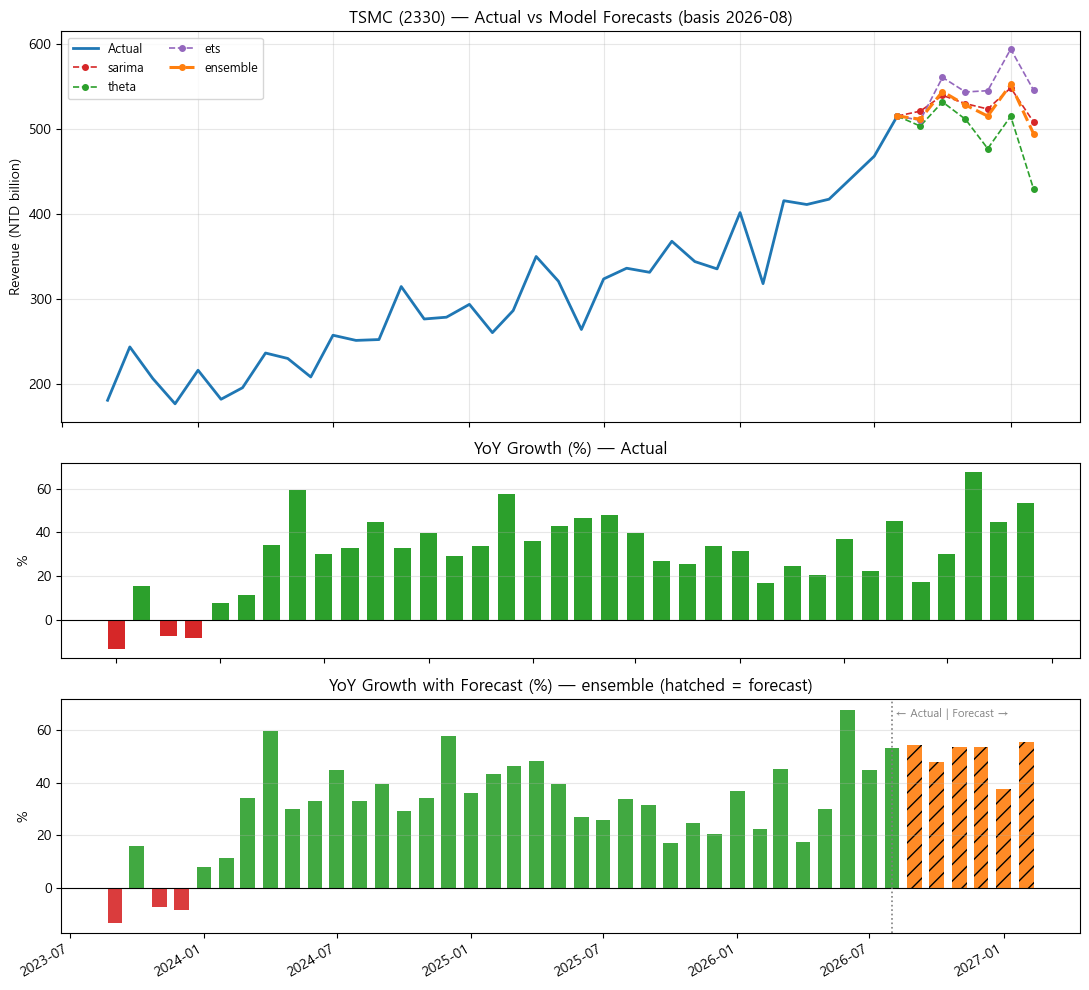

In [40]:
# 사용 예 1) 단일 ticker → 3단 비교 차트
# 하단 '예측 반영 YoY' 는 기본 ensemble. 다른 모델로 보려면:
#   analyze("2330", fc_model="sarima")   # sarima / theta / ets / ensemble
analyze("2330")

In [41]:
# 사용 예 2) ticker 리스트 → 과거 예측 이력 DataFrame
hist = analyze(["2330", "2454", "2317"], model="ensemble")   # model=None 이면 전체 모델
if not hist.empty:
    print(f"총 {len(hist)}행 | 실제치와 비교 가능: {hist['actual_bil'].notna().sum()}행")
hist.tail(15)

총 90행 | 실제치와 비교 가능: 9행


,company_id,name,model,basis,target,lead_m,predicted_bil,actual_bil,error_pct
75,2454,MediaTek,ensemble,2026-06,2027-10,16,56.1,NaN,NaN
76,2454,MediaTek,ensemble,2026-06,2027-11,17,56.4,NaN,NaN
77,2454,MediaTek,ensemble,2026-06,2027-12,18,57.1,NaN,NaN
78,2454,MediaTek,ensemble,2026-07,2026-08,1,52.0,64.2,-18.9
79,2454,MediaTek,ensemble,2026-07,2026-09,2,56.1,NaN,NaN
80,2454,MediaTek,ensemble,2026-07,2026-10,3,51.9,NaN,NaN
81,2454,MediaTek,ensemble,2026-07,2026-11,4,52.2,NaN,NaN
82,2454,MediaTek,ensemble,2026-07,2026-12,5,53.2,NaN,NaN
83,2454,MediaTek,ensemble,2026-07,2027-01,6,51.6,NaN,NaN
84,2454,MediaTek,ensemble,2026-08,2026-09,1,60.9,NaN,NaN


In [42]:
# (선택) 모델별 예측 정확도 요약 — 실제치가 발표된 예측만 대상
done = hist.dropna(subset=["actual_bil"]) if not hist.empty else hist
if not done.empty:
    acc = (done.assign(abs_err=done["error_pct"].abs())
               .groupby(["company_id", "name", "model"])
               .agg(n=("abs_err", "count"), MAPE=("abs_err", "mean"))
               .round(2))
    display(acc)
else:
    print("실제치가 발표된 과거 예측이 아직 없습니다.")

,,,n,MAPE
company_id,name,model,,
2317,Hon Hai (Foxconn),ensemble,3,7.9
2330,TSMC,ensemble,3,5.4
2454,MediaTek,ensemble,3,13.4


## 5. (선택) 노트북에서 바로 예측 실행

horizon을 바꿔가며 예측을 실행하고 결과를 즉시 확인할 수 있습니다. 결과는 DB에도 저장됩니다.

In [43]:
# HORIZON = 6   # ← 예측 개월 수 조정
#
# from forecaster import forecast_company
# result = forecast_company(conn, CID, horizon=HORIZON)  # 4개 모델 모두 실행/저장
# pd.DataFrame(result) if result else "관측치 부족 또는 실패"

In [44]:
conn.close()